In [5]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("bank.csv")
df


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


In [10]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


In [8]:
x = df.drop('deposit',axis=1)
y=df['deposit']

In [9]:
le = LabelEncoder()
y = le.fit_transform(y)
x = pd.get_dummies(x)

x

,age,balance,day,duration,campaign,pdays,previous,job_admin.,job_blue-collar,job_entrepreneur,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,59,2343,5,1042,1,-1,0,True,False,False,...,False,False,True,False,False,False,False,False,False,True
1,56,45,5,1467,1,-1,0,True,False,False,...,False,False,True,False,False,False,False,False,False,True
2,41,1270,5,1389,1,-1,0,False,False,False,...,False,False,True,False,False,False,False,False,False,True
3,55,2476,5,579,1,-1,0,False,False,False,...,False,False,True,False,False,False,False,False,False,True
4,54,184,5,673,2,-1,0,True,False,False,...,False,False,True,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,1,20,257,1,-1,0,False,True,False,...,False,False,False,False,False,False,False,False,False,True
11158,39,733,16,83,4,-1,0,False,False,False,...,True,False,False,False,False,False,False,False,False,True
11159,32,29,19,156,2,-1,0,False,False,False,...,False,False,False,False,False,False,False,False,False,True
11160,43,0,8,9,2,172,5,False,False,False,...,False,False,True,False,False,False,True,False,False,False


In [9]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [11]:
model = DecisionTreeClassifier(
    max_depth=7,
    min_samples_split=5,
    min_samples_leaf=10,
    random_state=42,
    criterion='gini'
)

model.fit(x_train,y_train)

NameError: name 'x_train' is not defined

In [ ]:
for depth in [3,5,7,9]:
    model = DecisionTreeClassifier(max_depth=depth,random_state=42)
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    print(accuracy_score(y_pred,y_test))


0.7693685624720108
0.7948947604120018
0.799373040752351
0.8069861173309449


In [13]:
accuracy_score_ans = accuracy_score(y_pred,y_test)
print("accuracy of model is ",accuracy_score_ans*100)


accuracy of model is  80.6986117330945


In [15]:
print("classification_report: \n",classification_report(y_pred,y_test))
print("confusion matrix: \n",confusion_matrix(y_pred,y_test))


classification_report: 
               precision    recall  f1-score   support

           0       0.77      0.85      0.81      1057
           1       0.85      0.77      0.81      1176

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.81      2233

confusion matrix: 
 [[896 161]
 [270 906]]


[Text(0.5108916938110749, 0.95, 'duration <= 205.5\ngini = 0.499\nsamples = 8929\nvalue = [4707, 4222]'),
 Text(0.2738701140065147, 0.85, 'poutcome_success <= 0.5\ngini = 0.322\nsamples = 3621\nvalue = [2890, 731]'),
 Text(0.39238090390879476, 0.8999999999999999, 'True  '),
 Text(0.19849348534201955, 0.75, 'month_mar <= 0.5\ngini = 0.266\nsamples = 3377\nvalue = [2843, 534]'),
 Text(0.13151465798045603, 0.65, 'duration <= 123.5\ngini = 0.245\nsamples = 3296\nvalue = [2826, 470]'),
 Text(0.0745114006514658, 0.55, 'month_oct <= 0.5\ngini = 0.107\nsamples = 1785\nvalue = [1684, 101]'),
 Text(0.04804560260586319, 0.45, 'month_feb <= 0.5\ngini = 0.096\nsamples = 1757\nvalue = [1668, 89]'),
 Text(0.026058631921824105, 0.35, 'month_apr <= 0.5\ngini = 0.074\nsamples = 1629\nvalue = [1566, 63]'),
 Text(0.013029315960912053, 0.25, 'month_sep <= 0.5\ngini = 0.054\nsamples = 1543\nvalue = [1500, 43]'),
 Text(0.006514657980456026, 0.15, 'pdays <= 382.0\ngini = 0.049\nsamples = 1528\nvalue = [1490, 

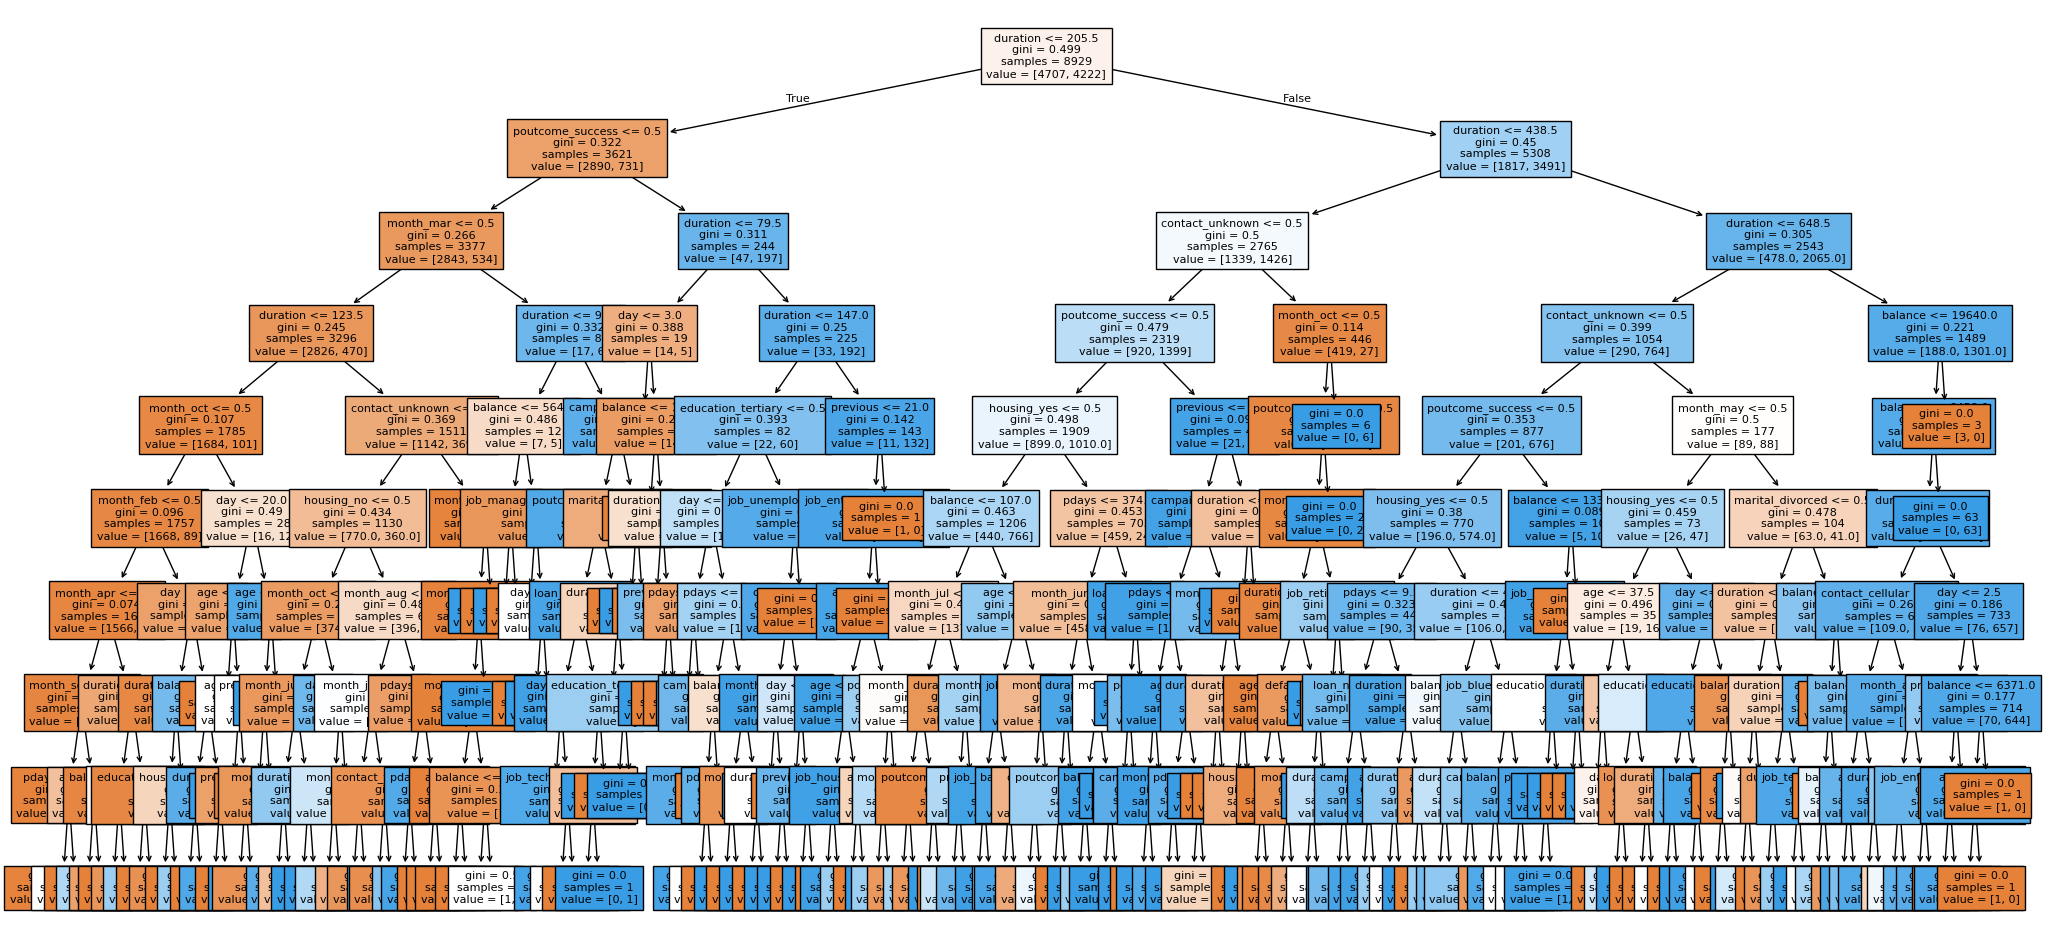

In [17]:
plt.figure(figsize=(25,12))
           
plot_tree(
    model,
    fontsize=8,
    filled=True,
    feature_names=x.columns
)